# Bibliotecas necessarias 


In [93]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

O nosso dataset trata-se do Desempenho dos alunos nos exames em diversas disciplinas ao fim do ensino médio.
Inicialmente vamos abrir o arquivo e associasr a uma variavel que vai ser o nosso dataframe


In [24]:
desempenho = pd.read_csv('StudentsPerformance.csv')
desempenho.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
desempenho.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


Vamos verificar quais os rotulos possiveis dos atributos

In [30]:
desempenho['gender'].unique()

array(['female', 'male'], dtype=object)

In [31]:
desempenho['race/ethnicity'].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

In [33]:
desempenho['parental level of education'].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [34]:
desempenho['lunch'].unique()

array(['standard', 'free/reduced'], dtype=object)

In [35]:
desempenho['test preparation course'].unique()

array(['none', 'completed'], dtype=object)

Vamos passar as colunas e os rotulos todos para o idioma português e tornar o projeto mais próximo de nosso cotidiano.

In [36]:
desempenho = desempenho.rename(columns={
    'gender': 'genero',
    'race/ethnicity': 'raca_etnia',
    'parental level of education': 'nivel_educacao_pais',
    'lunch': 'tipo_alimentacao',
    'test preparation course': 'curso_preparatorio',
    'math score': 'nota_matematica',
    'reading score': 'nota_leitura',
    'writing score': 'nota_escrita'
})

In [37]:
desempenho['genero'] = desempenho['genero'].replace({
    'female': 'feminino',
    'male': 'masculino'
})

In [38]:
desempenho['tipo_alimentacao'] = desempenho['tipo_alimentacao'].replace({
    'standard': 'padrao',
    'free/reduced': 'gratuito/reduzido'
})

In [39]:
desempenho['curso_preparatorio'] = desempenho['curso_preparatorio'].replace({
    'none': 'nenhum',
    'completed': 'completo'
})

In [40]:
desempenho['nivel_educacao_pais'] = desempenho['nivel_educacao_pais'].replace({
    "bachelor's degree": 'ensino_superior',
    "some college": 'faculdade_incompleta',
    "master's degree": 'mestrado',
    "associate's degree": 'tecnico',
    "high school": 'ensino_medio',
    "some high school": 'medio_incompleto'
})

In [41]:
desempenho['raca_etnia'] = desempenho['raca_etnia'].replace({
    'group A': 'grupo_A',
    'group B': 'grupo_B',
    'group C': 'grupo_C',
    'group D': 'grupo_D',
    'group E': 'grupo_E'
})

Agora vamos ver novamente as cinco primeiras linhas de nosso dataframe traduzido para o português.

In [42]:
desempenho.head()


,genero,raca_etnia,nivel_educacao_pais,tipo_alimentacao,curso_preparatorio,nota_matematica,nota_leitura,nota_escrita
0,feminino,grupo_B,ensino_superior,padrao,nenhum,72,72,74
1,feminino,grupo_C,faculdade_incompleta,padrao,completo,69,90,88
2,feminino,grupo_B,mestrado,padrao,nenhum,90,95,93
3,masculino,grupo_A,tecnico,gratuito/reduzido,nenhum,47,57,44
4,masculino,grupo_C,faculdade_incompleta,padrao,nenhum,76,78,75


# Vamos descrever as estatísticas básicas dos atributos notas de matematica, leitura e escrita.

In [43]:
desempenho.describe()

,nota_matematica,nota_leitura,nota_escrita
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Agora vamos verificar se temos linhas com falta de informação ou com informação nula.

In [44]:
desempenho.isnull().sum()


genero                 0
raca_etnia             0
nivel_educacao_pais    0
tipo_alimentacao       0
curso_preparatorio     0
nota_matematica        0
nota_leitura           0
nota_escrita           0
dtype: int64

# Vamos verificar a porcentagem de meninas e meninas que participaram dos testes

In [47]:
desempenho['genero'].value_counts(normalize=True)*100



genero
feminino     51.8
masculino    48.2
Name: proportion, dtype: float64

Podemos observar pelo percentual que tivemos mais mulheres fazendo o teste do homens.

In [77]:
desempenho.groupby(['genero'])['nota_matematica'].mean()

genero
feminino     63.633205
masculino    68.728216
Name: nota_matematica, dtype: float64

In [78]:
desempenho.groupby(['genero'])['nota_matematica'].median()

genero
feminino     65.0
masculino    69.0
Name: nota_matematica, dtype: float64

Observa-se que temos uma diferença no desempenho medio das mulheres em relação aos homens em matemática, algo reforçado pelo nossas medianas, ou seja de acordo com as médias e medianas, os homens tem um desempenho um pouco melhor do que as mulheres no teste de matemática. vamos tentar visualizar isso em um famos gráfico de Boxplot.

<Axes: xlabel='genero', ylabel='nota_matematica'>

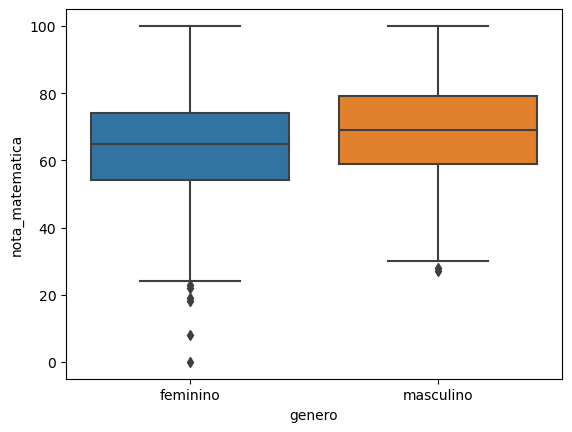

In [81]:
sns.boxplot( data = desempenho,x = 'genero',y = 'nota_matematica')


Podemos visualizar novamente uma peguena diferença de desempenho em matemática a favor dos homens ao mesmo tempo temos que observar alguns pontos bem abaixo do primeiro quartil por parte das mulheres e um box com dados mais dispersos que o dos homens. 

In [59]:
desempenho.groupby(['genero'])['nota_leitura'].mean()

genero
feminino     72.608108
masculino    65.473029
Name: nota_leitura, dtype: float64

In [82]:
desempenho.groupby(['genero'])['nota_leitura'].median()

genero
feminino     73.0
masculino    66.0
Name: nota_leitura, dtype: float64

Observa-se que temos uma diferença no desempenho medio das mulheres em relação aos homens em leitura, algo reforçado pelo nossas medianas, ou seja de acordo com as médias e medianas, as mulheres tem um desempenho melhor do que os homens no teste de leitura. vamos tentar visualizar isso em um famos gráfico de Boxplot.

<Axes: xlabel='genero', ylabel='nota_leitura'>

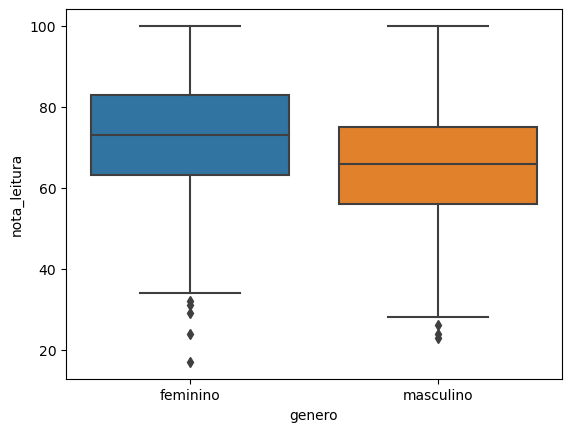

In [83]:
sns.boxplot(data = desempenho, x = 'genero', y = 'nota_leitura')

Podemos visualizar novamente uma diferença de desempenho em leitura a favor das mulheres ao mesmo tempo temos que observar alguns pontos bem abaixo do primeiro quartil por parte das mulheres e um box com dados mais dispersos que o dos homens.

In [60]:
desempenho.groupby(['genero'])['nota_escrita'].mean()

genero
feminino     72.467181
masculino    63.311203
Name: nota_escrita, dtype: float64

In [84]:
desempenho.groupby(['genero'])['nota_escrita'].median()

genero
feminino     74.0
masculino    64.0
Name: nota_escrita, dtype: float64

Observa-se que temos uma diferença no desempenho medio das mulheres em relação aos homens em escrita, algo reforçado pelo nossas medianas, ou seja de acordo com as médias e medianas, as mulheres tem um desempenho melhor do que os homens no teste de escrita. vamos tentar visualizar isso em um famos gráfico de Boxplot.

<Axes: xlabel='genero', ylabel='nota_escrita'>

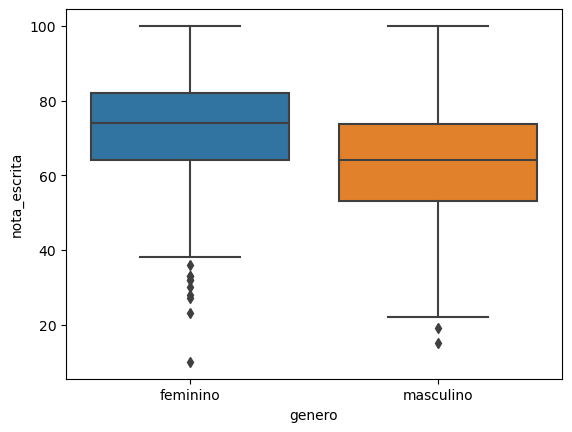

In [86]:
sns.boxplot(data = desempenho, x = 'genero', y = 'nota_escrita')

Podemos visualizar novamente uma diferença de desempenho em escrita a favor das mulheres ao mesmo tempo temos que observar alguns pontos bem abaixo do primeiro quartil por parte das mulheres e um box com dados mais dispersos que o dos homens.Acredito que das três comparações esse tenha a diferença mais significativa.

# Porcentagem de pessoas que fizeram os testes por Raça/Etnia

In [48]:
desempenho['raca_etnia'].value_counts(normalize=True)*100

raca_etnia
grupo_C    31.9
grupo_D    26.2
grupo_B    19.0
grupo_E    14.0
grupo_A     8.9
Name: proportion, dtype: float64

# Porcentagem de alunos participantes dos testes de acordo o nível de educação dos pais.

In [ ]:
desempenho['nivel_educacao_pais'].value_counts(normalize=True)*100

nivel_educacao_pais
faculdade_incompleta    22.6
tecnico                 22.2
ensino_medio            19.6
medio_incompleto        17.9
ensino_superior         11.8
mestrado                 5.9
Name: proportion, dtype: float64

# vamos fazer algumas verificações no desempenho dos alunos em função do nível de educação de seus pais em cada teste.

In [71]:
desempenho.groupby(['nivel_educacao_pais'])['nota_matematica'].mean().round(2)

nivel_educacao_pais
ensino_medio            62.14
ensino_superior         69.39
faculdade_incompleta    67.13
medio_incompleto        63.50
mestrado                69.75
tecnico                 67.88
Name: nota_matematica, dtype: float64

Aqui podemos observar que de acordo que o nível de instrução dos pais aumentam o desempenho do aluno em matemática também tende a aumentar.Vamos ver isso melhor em um gráfico.

Para fazer essa avaliação visual de uma maneira bem intuitiva, vou ter que ordenar os rótulos na coluna de nivel de educação dos pais.De maneira que teremos um avanço do nível de educação de ensino médio até mestrado.

In [91]:
ordenado = [ 'medio_incompleto','ensino_medio','tecnico','faculdade_incompleta','ensino_superior','mestrado']
desempenho['nivel_educacao_pais2'] = pd.Categorical(desempenho['nivel_educacao_pais'],categories=ordenado, ordered = True)
grafico_linha = desempenho.groupby(['genero','nivel_educacao_pais2'])[['nota_matematica','nota_leitura','nota_escrita']].mean().reset_index()

Agora que colocamos os rotulos em ordem, vamos fazer o gráfico de linha.

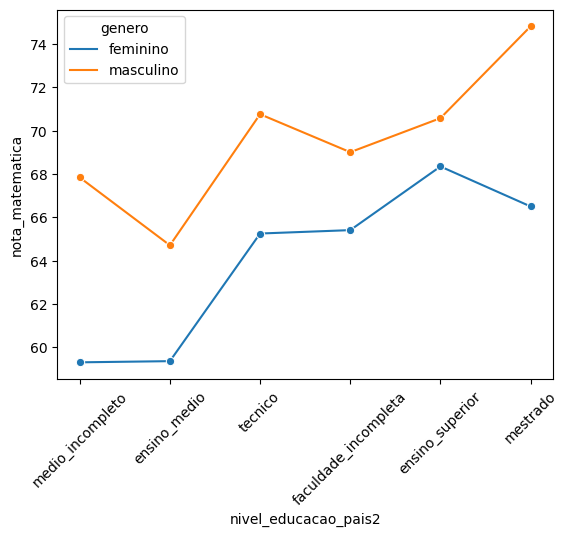

In [94]:
sns.lineplot(data = grafico_linha, x = 'nivel_educacao_pais2',y = 'nota_matematica', hue = 'genero',marker = 'o' )
plt.xticks(rotation = 45)
plt.show()

In [72]:
desempenho.groupby(['nivel_educacao_pais'])['nota_leitura'].mean().round(2)

nivel_educacao_pais
ensino_medio            64.70
ensino_superior         73.00
faculdade_incompleta    69.46
medio_incompleto        66.94
mestrado                75.37
tecnico                 70.93
Name: nota_leitura, dtype: float64

In [73]:
desempenho.groupby(['nivel_educacao_pais'])['nota_escrita'].mean().round(2)

nivel_educacao_pais
ensino_medio            62.45
ensino_superior         73.38
faculdade_incompleta    68.84
medio_incompleto        64.89
mestrado                75.68
tecnico                 69.90
Name: nota_escrita, dtype: float64

In [63]:
desempenho.groupby(['genero','nivel_educacao_pais'])['nota_matematica'].mean()

genero     nivel_educacao_pais 
feminino   ensino_medio            59.351064
           ensino_superior         68.349206
           faculdade_incompleta    65.406780
           medio_incompleto        59.296703
           mestrado                66.500000
           tecnico                 65.250000
masculino  ensino_medio            64.705882
           ensino_superior         70.581818
           faculdade_incompleta    69.009259
           medio_incompleto        67.840909
           mestrado                74.826087
           tecnico                 70.764151
Name: nota_matematica, dtype: float64

In [64]:
desempenho.groupby(['genero','nivel_educacao_pais'])['nota_leitura'].mean()

genero     nivel_educacao_pais 
feminino   ensino_medio            68.202128
           ensino_superior         77.285714
           faculdade_incompleta    73.550847
           medio_incompleto        69.109890
           mestrado                76.805556
           tecnico                 74.120690
masculino  ensino_medio            61.480392
           ensino_superior         68.090909
           faculdade_incompleta    64.990741
           medio_incompleto        64.693182
           mestrado                73.130435
           tecnico                 67.433962
Name: nota_leitura, dtype: float64

In [65]:
desempenho.groupby(['genero','nivel_educacao_pais'])['nota_escrita'].mean()

genero     nivel_educacao_pais 
feminino   ensino_medio            66.691489
           ensino_superior         78.380952
           faculdade_incompleta    74.050847
           medio_incompleto        68.285714
           mestrado                77.638889
           tecnico                 74.000000
masculino  ensino_medio            58.539216
           ensino_superior         67.654545
           faculdade_incompleta    63.148148
           medio_incompleto        61.375000
           mestrado                72.608696
           tecnico                 65.405660
Name: nota_escrita, dtype: float64

In [50]:
desempenho['tipo_alimentacao'].value_counts(normalize=True)*100

tipo_alimentacao
padrao               64.5
gratuito/reduzido    35.5
Name: proportion, dtype: float64

In [66]:
desempenho.groupby(['tipo_alimentacao'])['nota_matematica'].mean()

tipo_alimentacao
gratuito/reduzido    58.921127
padrao               70.034109
Name: nota_matematica, dtype: float64

In [67]:
desempenho.groupby(['tipo_alimentacao'])['nota_leitura'].mean()

tipo_alimentacao
gratuito/reduzido    64.653521
padrao               71.654264
Name: nota_leitura, dtype: float64

In [69]:
desempenho.groupby(['tipo_alimentacao'])['nota_escrita'].mean().round(2)

tipo_alimentacao
gratuito/reduzido    63.02
padrao               70.82
Name: nota_escrita, dtype: float64

In [51]:
desempenho['curso_preparatorio'].value_counts(normalize=True)*100

curso_preparatorio
nenhum      64.2
completo    35.8
Name: proportion, dtype: float64

In [74]:
desempenho.groupby(['curso_preparatorio'])[['nota_matematica','nota_leitura','nota_escrita']].mean().round(2)

,nota_matematica,nota_leitura,nota_escrita
curso_preparatorio,,,
completo,69.70,73.89,74.42
nenhum,64.08,66.53,64.50


Calculando as médias de notas dos alunos por sexo e materia

In [54]:
media_homens_matematica = desempenho[desempenho['genero']== 'masculino']['nota_matematica'].mean().round(2)
media_mulheres_matematica = desempenho[desempenho['genero']== 'feminino']['nota_matematica'].mean().round(2)
media_homens_leitura = desempenho[desempenho['genero']== 'masculino']['nota_leitura'].mean().round(2)
media_mulheres_leitura = desempenho[desempenho['genero']== 'feminino']['nota_leitura'].mean().round(2)
media_homens_escrita = desempenho[desempenho['genero']== 'masculino']['nota_escrita'].mean().round(2)
media_mulheres_escrita = desempenho[desempenho['genero']== 'feminino']['nota_escrita'].mean().round(2)
print('***************************************************************************')
print('------------------- Notas de acordo com Sexo -------------------------')
print('Nota média dos homens em matemática' ,media_homens_matematica)
print('Nota média das mulheres em matematica' ,media_mulheres_matematica)
print('Nota média dos homens em leitura' ,media_homens_leitura)
print('Nota média das mulheres em leitura' ,media_mulheres_leitura)
print('Nota média dos homens em escrita' ,media_homens_escrita)
print('Nota média das mulheres em escrita' ,media_mulheres_escrita)
print('****************************************************************************')


***************************************************************************
------------------- Notas de acordo com Sexo -------------------------
Nota média dos homens em matemática 68.73
Nota média das mulheres em matematica 63.63
Nota média dos homens em leitura 65.47
Nota média das mulheres em leitura 72.61
Nota média dos homens em escrita 63.31
Nota média das mulheres em escrita 72.47
****************************************************************************


Vamos verificar a média em relação a ter feito ou não curso preparatório.

In [57]:
desempenho.groupby(['genero', 'curso_preparatorio'])['nota_matematica'].mean()

genero     curso_preparatorio
feminino   completo              67.195652
           nenhum                61.670659
masculino  completo              72.339080
           nenhum                66.688312
Name: nota_matematica, dtype: float64